# 実行例5.1 ETL1手書き数字データベースの最近傍法による識別（p.57図5.4,図5.5）

- `Images`,`Colors` : ETL1ファイル読み込み用
- `ImageView` : サンプル表示用
- `StringEncodings` : JIS X 0201→UTF8変換用
- `ImageFiltering` : 画像を滑らかにするためのカーネル畳み込み用
- `ImageTransformations`,`Interpolations` : 画像のリサイズ用
- `StatsBase` : ランダムサンプリング用

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using CairoMakie
using Images
using Colors
using ImageView
using StringEncodings
using ImageFiltering
using ImageTransformations
using Interpolations
using StatsBase

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


## Ⅰ　ETL1データの前処理

### 1. フィールドデータの抽出コード
- Claude作成コード
- 手書き文字が何を示しているのか識別した結果はCharacter Code(`char_code`)やJIS Code（`jis_code`）になっている。

In [2]:
struct ETL1Record
    data_number::UInt16
    char_code::UInt16
    sheet_number::UInt16
    jis_code::UInt8
    ebcdic_code::UInt8
    eval_individual::UInt8
    eval_group::UInt8
    mat::Matrix{UInt8}
    image::Matrix{Gray{N0f8}}
end

function read_etl1(filepath)
    records = ETL1Record[]
    record_size = 2052
    
    open(filepath, "r") do f
        while !eof(f)
            data = read(f, record_size)
            length(data) < record_size && break
            
            # ヘッダ（ビッグエンディアン）
            data_number   = ntoh(reinterpret(UInt16, data[1:2])[1])
            char_code     = ntoh(reinterpret(UInt16, data[3:4])[1])
            sheet_number  = ntoh(reinterpret(UInt16, data[5:6])[1])
            jis_code      = data[7]
            ebcdic_code   = data[8]
            eval_individual = data[9]
            eval_group    = data[10]
            
            # 画像データ: 4bpp → 8bpp展開
            img_raw = data[33:2048]
            pixels = UInt8[]
            for byte in img_raw
                push!(pixels, (byte >> 4) * 17)
                push!(pixels, (byte & 0x0F) * 17)
            end
            
            # 63×64にreshape（行優先）してGray画像に
            mat = transpose(reshape(pixels[1:64*63], 64, 63))
            img = Gray{N0f8}.(mat ./ 255)   # 256階調のグレースケール
            # img = Gray{Bool}.(mat .> 128)   # 2値化
            
            push!(records, ETL1Record(
                data_number, char_code, sheet_number,
                jis_code, ebcdic_code, eval_individual, eval_group,
                mat, img
            ))
        end
    end
    
    return records
end

read_etl1 (generic function with 1 method)

- `struct`でフィールドごとの型を指定することでき、全体をまとめて型として定義できる。
- エンディアン（endian） : 2バイト以上のデータをメモリに置く場合の並び順（ビッグエンディアンは最初のバイトから並べ、リトリエンディアンは最後のバイトから並べる）
- `ntoh()` : ETL1のファイルはビッグエンディアン（上位バイトが先）で格納されているのに対しPCのCPU（x86）はリトルエンディアン（下位バイトが先）になっているため格納順を並び替える。
- `reinterpret()` : バイナリを符号なし整数（UInt）や浮動小数点（Float）などに再解釈する。UTFへの変換する場合は別途`Char()`や`String()`が必要。
- `(byte >> 4) * 17` : 各バイトの上位4ビットを取り出して17倍（0-15を0-255に変換）　※1バイトに2ピクセル分（4ビット×2）が詰まっている。
- `(byte & 0x0F) * 17` : 各バイトの下位4ビットを取り出して17倍（0-15を0-255に変換）　※1バイトに2ピクセル分（4ビット×2）が詰まっている。
- `byte = 0xA3（1010 0011）`の場合
    - `byte >> 4` : 右に4ビットシフト → 0000 1010 = 10（上位4ビットを取り出す）
    - `byte & 0x0F` : 0x0F=0000 1111とAND → 0000 0011 = 3（下位4ビットを取り出す）
- `Gray{N0f8}.(...)` : 各値をグレースケールのピクセル型に変換
- `mat ./ 255` : 0-255の値を0.0-1.0に正規化
- `Gray{Bool}.(...)` : 各値を2値のピクセル型に変換
- `mat .> 128` : 128より大きければtrue（白）、小さければfalse（黒）

### 2. ETL1ファイル読み込み

#### 2.1 ファイルのデータを`records`に変換

In [3]:
# (1)ファイルパスの指定
filepath = joinpath(@__DIR__, "ETL1C_01")

# (2)ファイルの読み込み
records = read_etl1(filepath)

11560-element Vector{ETL1Record}:
 ETL1Record(0x0001, 0x3020, 0x03e9, 0x30, 0xf0, 0x00, 0x00, UInt8[0x22 0x11 … 0x11 0x11; 0x11 0x11 … 0x22 0x11; … ; 0x11 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x11], Gray{N0f8}[0.133 0.067 … 0.067 0.067; 0.067 0.067 … 0.133 0.067; … ; 0.067 0.067 … 0.067 0.067; 0.067 0.067 … 0.067 0.067])
 ETL1Record(0x0002, 0x3020, 0x03ea, 0x30, 0xf0, 0x00, 0x00, UInt8[0x11 0x00 … 0x11 0x11; 0x11 0x11 … 0x11 0x11; … ; 0x11 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x00], Gray{N0f8}[0.067 0.0 … 0.067 0.067; 0.067 0.067 … 0.067 0.067; … ; 0.067 0.067 … 0.067 0.067; 0.067 0.067 … 0.067 0.0])
 ETL1Record(0x0003, 0x3020, 0x03eb, 0x30, 0xf0, 0x01, 0x00, UInt8[0x22 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x11; … ; 0x11 0x11 … 0x11 0x11; 0x11 0x22 … 0x11 0x11], Gray{N0f8}[0.133 0.067 … 0.067 0.067; 0.067 0.067 … 0.067 0.067; … ; 0.067 0.067 … 0.067 0.067; 0.067 0.133 … 0.067 0.067])
 ETL1Record(0x0004, 0x3020, 0x03ec, 0x30, 0xf0, 0x00, 0x00, UInt8[0x11 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x1

#### 【テスト】読み込んだサンプルの表示

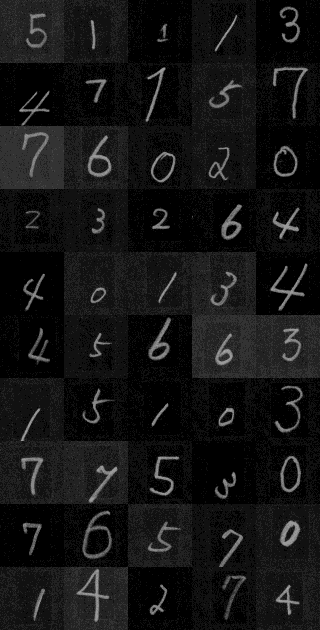

['5', '4', '7', '2', '4', '4', '1', '7', '7', '1', '1', '7', '6', '3', '0', '5', '5', '7', '6', '4', '1', '1', '0', '2', '1', '6', '1', '5', '5', '2', '1', '5', '2', '6', '3', '6', '0', '3', '7', '7', '3', '7', '0', '4', '4', '3', '3', '0', '0', '4']
["5", "4", "7", "2", "4", "4", "1", "7", "7", "1", "1", "7", "6", "3", "0", "5", "5", "7", "6", "4", "1", "1", "0", "2", "1", "6", "1", "5", "5", "2", "1", "5", "2", "6", "3", "6", "0", "3", "7", "7", "3", "7", "0", "4", "4", "3", "3", "0", "0", "4"]


In [4]:
# (1)表示するサンプル数
num_sample = 50

# (2)ランダムでサンプル取得
# 型指定
record_sample = ETL1Record[]
# サンプル取得
for i in 1:num_sample
    push!(record_sample, records[rand(1:length(records))])
end

# (3)個別のウィンドウで画像データ表示
# ⚠サンプルの数だけウィンドウが開く
# for i in 1:num_sample
#     println("JIS: 0x", string(record_sample[i].jis_code, base=16, pad=4))
#     imshow(records[i].image)
#     sleep(1)  # 1枚ずつ確認
# end

# (4)グリッドにまとめて画像データ表示
samples = [record_sample[i].image for i in 1:num_sample]
classes_ascii = [record_sample[i].char_code for i in 1:num_sample]
calsses_jis = [record_sample[i].jis_code for i in 1:num_sample]
mosaic_sample = mosaicview(samples..., nrow=10, ncols=5, fillvalue=Gray(1))
# imshow(mosaic)
display(collect(mosaic_sample))

# (5)ASCIIとJIS X 0201で画像の種別の確認
println([Char(c_askii >> 8)  for c_askii in classes_ascii])
println([decode([c_jis],"X0201") for c_jis in calsses_jis])

# (6)サンプルを保存
# save("etl1_sample.png", mosaic_sample)

- `Char(c_askii >> 8)` : ASCIIからUTF-8に変換
- `decode([c_jis],"X0201")` : JIS X 0201からUTF-8に変換（`StringEncodings.jl`の関数）
- 通常の画像データは`Matrix`型で変数だけで表示されるが`MosaicView`型は特殊なため一工夫要る。`collect()`で実体化（配列化）して、それでも表示されない場合は`display()`で明示的に表示させる。

### 3. 画像の正規化

#### 3.1 手書き文字の切り抜きと位置ズレの補正

In [5]:
# 閾値調整
threshold_mat = 96
threshold_gray = threshold_mat / 255

# (1)グレースケール状態での手書き部分の切り抜き（正方形）
function img_cutting_gray(img)
    # ①手書き位置の確認
    # 一番端のピクセル位置の初期化
    p_top, p_bottom, p_left, p_right = 63, 1, 64, 1
    # 手書き文字と認識する閾値の設定
    p_threshold = threshold_gray
    # 一番端のピクセル位置の探索
    for i in 1:63
        for j in 1:64
            if img[i, j] > p_threshold
                if i < p_top
                    p_top = i
                end
                if i > p_bottom
                    p_bottom = i
                end
                
                if j < p_left
                    p_left = j
                end
                if j > p_right
                    p_right = j
                end
            end
        end
    end
    # 【テスト】上下左右の端の位置の確認
    # println(p_top, ":", p_bottom, ":", p_left, ":", p_right)

    # ②切り抜きサイズの確認
    # 上下と左右の幅の広さを比較
    # 文字の書かれている箇所を正方形で切り抜くための辺の長さの確認
    square_cut = 0
    # 文字の位置ずれを補正
    shift_width, shift_hight = 0, 0
    if (p_bottom - p_top) > (p_right - p_left)
        square_cut = p_bottom - p_top
        shift_width = ((p_bottom - p_top) - (p_right - p_left)) ÷ 2
    else
        square_cut = p_right - p_left
        shift_hight = ((p_right - p_left) - (p_bottom - p_top)) ÷ 2
    end

    # ③切り抜くにあたって長さが足りないところを黒いピクセルで埋めておく
    # 元の画像サイズ
    h, w = size(img)  # 63, 64
    # 長手方向の長さ
    height = p_bottom - p_top
    width = p_right - p_left
    square = max(height, width)
    # 必要なパディング量
    pad_bottom = max(0, p_top + square - h)
    pad_right  = max(0, p_left + square - w)
    # 黒ピクセルでパディング
    new_h = h + pad_bottom
    new_w = w + pad_right
    padded = fill(Gray{N0f8}(0), new_h, new_w)  # グレースケールでパディング
    padded[1:h, 1:w] = img

    # ④正方形に切り抜き
    # cutting_image = padded[p_top - shift_hight:p_top + square_cut, p_left - shift_width : p_left + square_cut]
    row_start = max(1, p_top - shift_hight)
    row_end   = min(new_h, row_start + square_cut)
    col_start = max(1, p_left - shift_width)
    col_end   = min(new_w, col_start + square_cut)
    cutting_image = padded[row_start:row_end, col_start:col_end]

    return cutting_image, square    # 切り抜き結果の画像、画像の辺の長さ
end

# (2)オリジナル状態での手書き部分の切り抜き（正方形）
function img_cutting_mat(mat::Matrix{UInt8})
    # ①手書き位置の確認
    # 一番端のピクセル位置の初期化
    p_top, p_bottom, p_left, p_right = 63, 1, 64, 1
    # 手書き文字と認識する閾値の設定
    p_threshold = threshold_mat
    # 一番端のピクセル位置の探索
    for i in 1:63
        for j in 1:64
            if mat[i, j] > p_threshold
                if i < p_top
                    p_top = i
                end
                if i > p_bottom
                    p_bottom = i
                end
                
                if j < p_left
                    p_left = j
                end
                if j > p_right
                    p_right = j
                end
            end
        end
    end
    # 【テスト】上下左右の端の位置の確認
    # println(p_top, ":", p_bottom, ":", p_left, ":", p_right)

    # ②切り抜きサイズの確認
    # 上下と左右の幅の広さを比較
    # 文字の書かれている箇所を正方形で切り抜くための辺の長さの確認
    square_cut = 0
    # 文字の位置ずれを補正
    shift_width, shift_hight = 0, 0
    if (p_bottom - p_top) > (p_right - p_left)
        square_cut = p_bottom - p_top
        shift_width = ((p_bottom - p_top) - (p_right - p_left)) ÷ 2
    else
        square_cut = p_right - p_left
        shift_hight = ((p_right - p_left) - (p_bottom - p_top)) ÷ 2
    end

    # ③切り抜くにあたって長さが足りないところを黒いピクセルで埋めておく
    # 元の画像サイズ
    h, w = size(mat)  # 63, 64
    # 長手方向の長さ
    height = p_bottom - p_top
    width = p_right - p_left
    square = max(height, width)
    # 必要なパディング量
    pad_bottom = max(0, p_top + square - h)
    pad_right  = max(0, p_left + square - w)
    # 黒ピクセルでパディング
    new_h = h + pad_bottom
    new_w = w + pad_right
    padded = fill(UInt8(0), new_h, new_w)   # オリジナル状態でパディング
    padded[1:h, 1:w] = mat

    # ④正方形に切り抜き
    # cutting_mat = padded[p_top - shift_hight:p_top + square_cut, p_left - shift_width : p_left + square_cut]
    row_start = max(1, p_top - shift_hight)
    row_end   = min(new_h, row_start + square_cut)
    col_start = max(1, p_left - shift_width)
    col_end   = min(new_w, col_start + square_cut)
    cutting_mat = padded[row_start:row_end, col_start:col_end]

    return cutting_mat, square    # 切り抜き結果の画像、画像の辺の長さ
end

img_cutting_mat (generic function with 1 method)

- img[i, j]のiは行（上下方向）、jは列（左右方向）
- `÷` : 商だけ取る。`\div`でtab変換できる。`Int()`は型変換だけで小数点には使えない。
- `round(Int, x)`,`floor(Int, x)`,`ceil(Int, x)` : それぞれ四捨五入、切り捨て、切り上げ
- 正方形に切り抜く場合に下記のままだと境界外にはみ出して`BoundsError`になることがある。そのためインデックス計算にクランプを追加する。
```
utting_mat = padded[p_top - shift_hight:p_top + square_cut, p_left - shift_width : p_left + square_cut]
```

#### 【テスト】切り抜きの確認

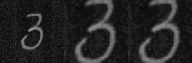

In [6]:
# 対象サンプル
# n = 8249
n = 5490
# 切り抜き
cutting_image = img_cutting_gray(records[n].image)[1]   # グレースケールの切り抜き
cutting_mat = img_cutting_mat(records[n].mat)[1]    # オリジナルで切り抜き
# imshow(records[n].image)
# save("etl1_no_cutting.png", records[n].image)
# imshow(cutting_image)
# save("etl1_cutting.png", cutting_image)
# img出力用加工
output_image = imresize(cutting_image, size(records[n].image))
output_mat = imresize(Gray{N0f8}.(cutting_mat ./ 255), size(records[n].image))
[records[n].image output_image output_mat]
# [records[n].image ; resize_image]

- 画像データを[]で配列するとアウトプットセルに並べて表示できる。半角スペースなら横並び、`;`を使えば縦並び（通常の配列と同じ）
- ただし並べるデータのサイズを揃える必要があり、`resize_image = imresize(cutting_image, size(records[n].image))`で処理している。

#### 3.2 リサイズ
- `imresize()`を使って切り出した画像を`16×16ピクセルにサイズ変更する。
- `imresize()` : `ImageTransformations.jl`の関数
- `BSpline` : `Interpolations.jl`の関数
- `Cubic()`は浮動小数点しか扱えないので引数はグレースケールの`img`ではなくオリジナルの`mat`を使用する。

In [7]:
img = cutting_mat
img_f = float.(channelview(img))
@show typeof(img_f)  # Gray{Float64}になっているか確認

typeof(img_f) = Matrix{Float64}


Matrix{Float64} (alias for Array{Float64, 2})

In [8]:
# (1) リサイズ
function img_resize(mat, alg=1)
    #=
    mat⇒
    alg⇒
        1:Bicubic
        2:Bilinear
        3:Nearest neighbor
    =#
    
    if alg == 1
        resized_image = imresize(mat, (16, 16), method=BSpline(Cubic(Line(OnGrid()))))
    elseif alg == 2
        resized_image = imresize(mat, (16, 16), method=BSpline(Linear()))
    elseif alg == 3
        resized_image = imresize(mat, (16, 16), method=BSpline(Constant()))
    else
        resized_image = mat
    end

    return resized_image
end

img_resize (generic function with 2 methods)

#### 【テスト】リサイズの確認

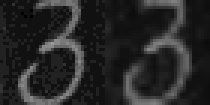

In [9]:
# リサイズ手法の指定
#=
alg⇒
    1:Bicubic
    2:Bilinear
    3:Nearest neighbor
=#
alg = 1
# 切り抜き画像を指定
#=
arg⇒::Matrix{UInt8}
=#
mat = cutting_mat
# リサイズ
resized_mat = img_resize(mat, alg) 
# 出力用加工
resize_image = imresize(Gray{N0f8}.(resized_mat ./ 255), size(cutting_image))
[cutting_image resize_image]

#### 3.3 フィルター処理
- フィルター用のカーネルを準備して、`imfilter()`で処理をする。
- `imfilter()` : `ImageFiltering.jl`の関数

In [10]:
# (1) ガウシアンフィルター
# ガウシアンカーネル
function gaussian_kernel(size, sigma)
    k = zeros(size, size)
    c = size ÷ 2 + 1
    for i in 1:size
        for j in 1:size
            x = i - c
            y = j - c
            k[i, j] = exp(-(x^2 + y^2) / (2 * sigma^2))
        end
    end
    k ./= sum(k)
    return k
end

# ガウシアンフィルター
function gaussian_filter(img, kernel_size=5, sigma=1.0)
    k = gaussian_kernel(kernel_size, sigma)
    return imfilter(img, k)
end

# (2)cos-sinフィルター（x-y軸方向だけで計算）
# cos-sinカーネル（x-y軸方向）
function cossin_kernel_2axis(size, sigma=1.0)
    k = zeros(size, size)
    c = size ÷ 2 + 1
    for i in 1:size
        for j in 1:size
            x = (i - c) / (size * sigma) * 2π
            y = (j - c) / (size * sigma) * 2π
            k[i, j] = (cos(sin(x) + sin(y) + x + y) + 1) / 2
        end
    end
    k ./= sum(k)
    return k
end

# cos-sinフィルター（x-y軸方向）
function cossin_filter_2axis(img, kernel_size=5, sigma=1.0)
    k = cossin_kernel_2axis(kernel_size)
    return imfilter(img, k)
end

# (3)cos-sinフィルター（中心からの距離で計算）
# cos-sinカーネル（中心からの等距離）
function cossin_kernel_radial(size, sigma=1.0)
    k = zeros(size, size)
    c = size ÷ 2 + 1
    for i in 1:size
        for j in 1:size
            x = i - c
            y = j - c
            r = sqrt(x^2 + y^2) / (size * sigma) * 2π
            k[i, j] = (cos(sin(r) + r) + 1) / 2
        end
    end
    k ./= sum(k)
    return k
end

# cos-sinフィルター（中心からの距離）
function cossin_filter_radial(img, kernel_size=5, sigma=1.0)
    k = cossin_kernel_radial(kernel_size)
    return imfilter(img, k)
end

# (4)cos-arctanフィルター（中心からの距離で計算）
# cos-arctanカーネル（中心からの等距離）
function cosatan_kernel_radial(size, sigma=1.0)
    k = zeros(size, size)
    c = size ÷ 2 + 1
    for i in 1:size
        for j in 1:size
            x = i - c
            y = j - c
            r = sqrt(x^2 + y^2) / (size * sigma) * 2π
            k[i, j] = (cos(2 * atan(r)))
        end
    end
    k ./= sum(k)
    return k
end

# cos-arctanフィルター（中心からの距離）
function cosatan_filter_radial(img, kernel_size=5, sigma=1.0)
    k = cosatan_kernel_radial(kernel_size)
    return imfilter(img, k)
end

cosatan_filter_radial (generic function with 3 methods)

- `kernel_size` : 畳み込みで参照する近傍ピクセルの範囲
- `sigma` : 分布の広がりを制御するパラメーター
    - 小さい（例：0.5）: 中心の重みが強く、ぼけが弱い
    - 大きい（例：2.0）: 重みが広がり、ぼけが強い

#### 【テスト】フィルター処理の確認

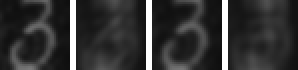

In [11]:
# (1)フィルター変数の指定
kernel_size = 12
sigma = 1.0

# (2)フィルター処理
# img_gaussian = gaussian_filter(records[n].image, kernel_size, sigma)
# img_cossin_2axis = cossin_filter_2axis(records[n].image, kernel_size, sigma)
# img_cossin_radial = cossin_filter_radial(records[n].image, kernel_size, sigma)
img_gaussian = gaussian_filter(resize_image, kernel_size, sigma)
img_cossin_2axis = cossin_filter_2axis(resize_image, kernel_size, sigma)
img_cossin_radial = cossin_filter_radial(resize_image, kernel_size, sigma)
img_cosatan_radial = cosatan_filter_radial(resize_image, kernel_size, sigma)

# (3)グリッドにまとめる
mosaic_filttering = mosaicview([img_gaussian, img_cossin_2axis, img_cossin_radial, img_cosatan_radial], nrow=1, ncol=4, npad=3, fillvalue=Gray(1.0))

# (4)表示
# imshow(img_gaussian)
# imshow(img_cossin_2axis)
# imshow(img_cossin_radial)
# imshow(img_cosatan_radial)
# display([img_gaussian img_cossin_2axis img_cossin_radial img_cosatan_radial])
display(collect(mosaic_filttering))

# (5)保存
# save("etl1_gaussian.png", img_gaussian)
# save("etl1_cossin_2axis.png", img_cossin_2axis)
# save("etl1_cossin_radial.png", img_cossin_radial)
# save("etl1_cosatan_radial.png", img_cosatan_radial)
save("etl1_fittered.png", mosaic_filttering)

- `mosaicview()`の引数として画像（配列）を`[a b c]`で並べると1つの配列として扱い`ncol`に合わせて空白が入る。リスト`[a, b, c]` で指定する必要がある。

### 4. 数字データの準備
- 数字データはファイルETL1C_01（全データ）とETL1C_02（一部データ、他にA～Fが含まれている）に分けて格納されている。
- 1人当たり0～9まで10種類の数字データが1,445人分含まれている。
- 実行例5.1では下記条件でデータを扱っている。
    1. 各数字1,300個をランダムに選び
    2. 各650個を学習データ
    3. 残りの650個をテストデータ
    4. 必ず何かの数字に認識できるものとする（リジェクトなし）
- 書かれた文字が何かはCharacter Codeで判断する。
- 同じ人が書いたかどうかはSerial Sheet Numberで判別できるものと思われる。
    参照：手書文字読取用紙記入上のお願い（https://etlcdb.db.aist.go.jp/etlcdb/etln/etl1/e1inst.jpg）
- 上記から、ここでは以下のデータセットを定義し直して取得する。
    - `data_number` : Data Number
    - `char_code` : Character Code
    - `writer_id` : Serial Sheet Number　※使うかどうかは未定
    - `raw_image` : 16 Gray Level (4bit/pixel) Image Data
    - `test_image` : `raw_image`を16×16サイズに加工したもの

#### 4.1 データの準備用関数
- 画像にフィルターをかけるアンチエイリアシング処理はリサイズ（ダウンサンプリング）の前に行うのが画像処理・信号処理における鉄則。
- 高解像度の画像を小さくするとき、画像の画素（ピクセル）を間引くことになる。ここで、フィルターをかけずに単純に間引いてしまうと、元の画像にあった細かい模様や高周波な成分が、サンプリング定理の限界（ナイキスト周波数）を超えてしまい、「モアレ（縞模様）」や「ジャギー（ギザギザ）」といった偽のノイズ（エイリアシング）として現れる。あらかじめリサイズ前にガウシアンフィルター（ローパスフィルター）をかけて画像を少しぼかしておくことで、間引いたときにノイズになる原因（高周波成分）をあらかじめカットできる。


In [12]:
# (1)データの定義
struct ETL1normalNN
    data_number::UInt16
    char_code::UInt16
    writer_id::UInt16
    raw_image::Matrix{UInt8}
    test_image::Matrix{UInt8}
end

# (2)ファイルパスの指定
file_01 = joinpath(@__DIR__, "ETL1C_01")
file_02 = joinpath(@__DIR__, "ETL1C_02")

# (3)ファイルの読み込み関数
function read_and_strange(filepath)
    records_normalNN = ETL1normalNN[]
    record_size = 2052
    
    open(filepath, "r") do io
        while !eof(io)
            data = read(io, record_size)
            length(data) < record_size && break
            
            # Metadata
            data_number = ntoh(reinterpret(UInt16, data[1:2])[1])
            char_code   = ntoh(reinterpret(UInt16, data[3:4])[1])
            writer_id   = ntoh(reinterpret(UInt16, data[5:6])[1])
            
            # Image data(raw_image)
            image_data = data[33:2048]
            pixels = UInt8[]
            for byte in image_data
                push!(pixels, (byte >> 4) * 17)
                push!(pixels, (byte & 0x0F) * 17)
            end
            raw_image = transpose(reshape(pixels[1:64*63], 64, 63))

            # Image data(test_image)
            # 切り抜きと位置ズレの補正
            temp_img = img_cutting_mat(Matrix(raw_image))[1]
            # フィルターでアンチエイリアシング 
            temp_img = gaussian_filter(temp_img, 5, 10)
            # リサイズ
            # if size(temp_img, 1) == 0
            if size(temp_img, 1) < 5 || size(temp_img, 2) < 5
                temp_img = zeros(UInt8, 16, 16)
            else
                temp_img  = img_resize(temp_img, 1)
            end
            test_image = UInt8.(round.(clamp.(temp_img, 0, 255)))

            push!(records_normalNN, ETL1normalNN(
                data_number,
                char_code,
                writer_id,
                raw_image,
                test_image
            ))
        end
    end

    return records_normalNN
end

read_and_strange (generic function with 1 method)

- `raw_image`は`Transpose{UInt8, Matrix{UInt8}}`という遅延型になっていて`Matrix{UInt8}`ではないため`temp_img = img_cutting_mat(raw_image)[1]`のままだとエラーになる。そのため`Matrix()`で``raw_image`をラップして実体化する。
- `function gaussian_filter(img, kernel_size=5, sigma=1.0)`が位置引数のため、`temp_img = gaussian_filter(temp_img, kernel_size=5, sigma=10)`で呼ぶとエラーになる。`temp_img = gaussian_filter(temp_img, 5, 10)`で呼ぶか、関数定義を`function gaussian_filter(img; kernel_size=5, sigma=1.0)`のようにセミコロンで区切る（セミコロンの前が位置引数、後ろがキーワード引数）。
- `test_image = gaussian_filter(temp_img, 5, 10)`のままだと`gaussian_filter`が`Matrix{Float64}`を返すのに`struct`の`test_image::Matrix{UInt8}`に代入しようとしてエラーになる。`UInt`への変換が必要。`test_image = UInt8.(round.(clamp.(gaussian_filter(temp_img, 5, 10), 0, 255)))`
- `clamp(x, lo, hi)` : `lo`~`hi`の間に収める関数。今回の場合はガウシアンフィルター後に浮動小数点の丸め誤差で255を超えたり0未満になったりする値を0〜255に収めるために使う。それをしないと`UInt8`に変換するときに`InexactError`になる。
- アンチエイリアシング後（正確には切り抜きと位置ズレの補正の後）にサイズが`(0, 0)`になることがあり、そのままだと`image_resize()`でエラーになるため、`size()`判定をした上で`(0, 0)`なら16×16全面黒の画像をダミーとして代入している。
- `test_image`の型に合わせるため`UInt8.(round.(clamp.(temp_img, 0, 255)))`で合わせている。`UInt8`は0~255の値を取る。

#### 4.2 ファイルの読み込みと数字データの抽出

In [13]:
# (1)ファイルの読み込み
records_normalNN = read_and_strange(file_01)
append!(records_normalNN, read_and_strange(file_02))

# (2)数字データを抽出
records_digits = filter(r -> 0x3020 <= r.char_code <= 0x3920, records_normalNN)
length(records_digits)

14450

#### 【テスト】読み込んだサンプルの表示

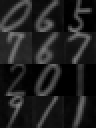

['0', '7', '2', '9', '6', '6', '0', '1', '5', '7', '1', '1']


In [14]:
# test

# (1)表示するサンプル数
num_sample = 12

# (2)ランダムでサンプル取得
# 型指定
record_sample = ETL1normalNN[]
# サンプル取得
for i in 1:num_sample
    push!(record_sample, records_digits[rand(1:length(records_digits))])
end

# (3)グリッドにまとめて画像データ表示
samples = [Gray{N0f8}.(record_sample[i].test_image ./ 255) for i in 1:num_sample]
classes_ascii = [record_sample[i].char_code for i in 1:num_sample]
mosaic_sample = mosaicview(samples..., nrow=4, ncols=3, fillvalue=Gray(1))
display(collect(mosaic_sample))

# (4)ASCIIで画像の種別の確認
println([Char(c_askii >> 8)  for c_askii in classes_ascii])

# (5)サンプルを保存
save("etl1_normalNN_sample.png", mosaic_sample)

#### 4.3 学習/テスト用サンプル抽出
- 各数字ごとに650個の学習データと、これと重複しない650個のテストデータをランダムで取り出す。


In [22]:
# (1)学習用とテスト用のサンプル番号準備関数
function random_sample_i(N=1400, smpl=650)
    # N : 母数, smpl : サンプル数
    # 学習用サンプル番号
    i_train = sample(1:N, smpl)
    # 学習用サンプルの残り
    i_leftover = setdiff(collect(1:N), i_train)
    # テスト用サンプル番号
    i_test = sample(i_leftover, smpl)

    return i_train, i_test
end

# (2)IntをASCII/ASCIIをIntに変換
function int_to_ascii(n)
    ascii = UInt16((0x30 + n) << 8 | 0x20)
    return ascii
end

function ascii_to_int(ascii::UInt16)
    return Int((ascii >> 8) - 0x30)
end


# (3)サンプリング関数
function sample_extracted(digit)
    # digit : 抽出対象の数字（0~9）
    # 対象レコードの抽出（母数）
    records_population = filter(r -> r.char_code == int_to_ascii(digit), records_digits)
    # 母数の数
    N = length(records_population)
    # サンプリング数
    smpl = 650
    # サンプリング対象番号配列
    i_train, i_test = random_sample_i(N, smpl)
    # 学習用データセット
    records_train = [records_population[i] for i in i_train]
    # テスト用データセット
    records_test = [records_population[i] for i in i_test]
    
    return records_train, records_test
end

# (4)サンプリング
# サンプリング
# 第1要素 : クラス
# 第2要素 : 学習データセット/テストデータセット
data_train = Dict{Int64, Vector{ETL1normalNN}}()
data_test = Dict{Int64, Vector{ETL1normalNN}}()
for i in 0:9
    records_sampled = sample_extracted(i)
    data_train[i] = records_sampled[1]
    data_test[i] = records_sampled[2]
end
    

- `char_code`はASCIIコードな点に注意。
- `Int`からASCIIコードへの変換関数は宣言無しでも書ける。
```
int_to_charcode(n) = UInt16((0x30 + n) << 8 | 0x20)
```
- `>>`は右シフト、`<<`は左シフト

#### 【テスト】サンプリングテスト

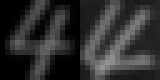

In [23]:
# test 
# 数字データの抜き出し
# test = sample_extracted(3)
# img1 = Gray{N0f8}.(test[1][10].raw_image ./ 255)
# img2 = Gray{N0f8}.(test[1][10].test_image ./ 255)
img1 = Gray{N0f8}.(data_train[4][10].test_image ./ 255)
img2 = Gray{N0f8}.(data_test[4][10].test_image ./ 255)
mosaic = mosaicview([img1, img2], nrow=1)
save("etl1_NN_test_sample.png", mosaic)
mosaic

### 5. 識別
- テストデータ（`data_test`）から一番近い学習データ（`data_train`）を探索する。

#### 5.1 識別関数
- 本来は一番ユークリッド距離が短いデータを探すが、結果として二乗和のままでも $\sqrt(\bar{x} - x)$ やノルム $|x|$ でも結果は変わらないため、計算不可の観点から $^2$ のままで処理をする。
- 比較するのは16×16ピクセルの画像データ同士で、いったんフラット化（256個の1次元ベクトルに変換）するのが本来のやり方だが、Juliaの場合、`Matrix`のままでも計算可能。

In [24]:
# (1)距離の総和の計算関数（実際には二乗和の計算）
function distance(x::Matrix{UInt8}, x_train::Vector{ETL1normalNN})
    distances = [sum((Int.(x) .- Int.(xi.test_image)).^2) for xi in x_train]

    return distances
end

# (2)距離の総和が最小になるクラスの判定関数
function minimum_distance(x::Matrix{UInt8})
    d = Dict{Int64, Int64}[]
    min_class = -1
    min_dist = Inf
    min_train = data_train[0][1]
    for i in 0:9
        x_train = data_train[i]
        # d = minimum(distance(x, x_train))
        d_list = distance(x, x_train)
        idx = argmin(d_list)
        d = d_list[idx]
        if d < min_dist
            min_dist = d
            min_class = i
            min_train = x_train[idx]  # 最近傍
        end
    end
    
    return min_class, min_dist, min_train
end

minimum_distance (generic function with 1 method)

- `Inf` : 正の無限大
- 判定の初期値としてクラスは`-1`、距離は正の無限大を与えている。

4の429番目
Matrix{UInt8}
Dict{Int64, Vector{ETL1normalNN}}
(4, 78390, ETL1normalNN(0x04cb, 0x3420, 0x0a3e, UInt8[0x33 0x33 0x33 0x22 0x33 0x33 0x33 0x22 0x22 0x33 0x33 0x33 0x33 0x22 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x22 0x33 0x33 0x22 0x22 0x33 0x33 0x33 0x22 0x33 0x22 0x33 0x22 0x33 0x33 0x33 0x33 0x22 0x33 0x33 0x33 0x22 0x33 0x22 0x33 0x22 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x22 0x33 0x22 0x33 0x33; 0x33 0x33 0x33 0x22 0x33 0x33 0x33 0x33 0x22 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x22 0x33 0x33 0x22 0x22 0x33 0x33 0x33; 0x33 0x33 0x33 0x33 0x33 0x22 0x33 0x33 0x33 0x22 0x33 0x33 0x33 0x33 0x22 0x33 0x33 0x22 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x33 0x22 0x33 0x22 0x33 0x22 0x33 0x33 0x22 0x22 0x33 0x22 0x33 0x33 0x33 0x33 0x11 0x33 0x33 0x22 0x22 0x22 0x33 0x22 0x2

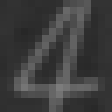

In [25]:
# test

digit_test = rand(0:9)
i_test = rand(1:650)
println(digit_test, "の", i_test, "番目")
test = data_test[digit_test][i_test]


x = test.test_image
println(typeof(x))
x_train = data_train
println(typeof(x_train))

recog = minimum_distance(x)

println(recog)

correct = ascii_to_int(test.char_code)

println(recog[1] == correct)

img = Gray{N0f8}.(test.test_image ./ 255)
save("etl1_recog_rsult.png", img)
img


- 距離の計算で`Matix`に`Int.()`を使っているのは、`UInt8`の引き算でアンダーフローが起きるのを防ぐため。`UInt8`は0~255の範囲でしか表現できないため引き算の結果がマイナスになると正しく計算できない。

#### 5.2 学習データの識別

In [26]:
# (1)誤識別データの格納変数の準備
# 第1要素 : 誤識別したデータ
# 第2要素 : 誤識別した結果のクラス
# 第3要素 : 誤識別した最近傍の学習データ
fault_result = Vector{Tuple{ETL1normalNN, Int64, ETL1normalNN}}()

# (2)学習データの識別
for x in data_test[2]
    recog_result = minimum_distance(x.test_image)
    correct_class = x.char_code
    if recog_result[1] != ascii_to_int(x.char_code)
        # println(typeof(recog_result[1]))
        push!(fault_result, (x, recog_result[1], recog_result[3]))
    end
end

# (3)誤識別率
# 誤識別件数
N_error = length(fault_result)
# 誤識別率
Error_rate = N_error / (650 * 10)

println(round((Error_rate * 100), digits=2), "%")

0.52%


#### 【テスト】誤識別結果の例

16


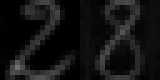

In [32]:
i = rand(1:length(fault_result))
println(i)

img1 = Gray{N0f8}.(fault_result[i][1].test_image ./ 255)
img2 = Gray{N0f8}.(fault_result[i][3].test_image ./ 255)

mosaic = mosaicview([img1, img2], nrow=1)
save("etl1_NN_result_sample.png", mosaic)
mosaic

### 【参考】ETL1データフォーマット
https://etlcdb.db.aist.go.jp/etlcdb/etln/form_m.htm

In [28]:
/---[form_m.htm 2001-09.04]-------------------------------------------------------------------

				M-Type Data Format	(ETL1, ETL6, ETL7)


1. File Format (Fixed Record Length without Control Words)

                   <----------> Logical record (2052 bytes) (1byte = 8bits)
     ------------------------------------------------------------------
     |  Sample 1  |  Sample 2  |  Sample 3  |    ....    |  Sample N  |  (No. of records = N)
     ------------------------------------------------------------------


2. Contents of Logical Record (2052 bytes)

 --------------------------------------------------------------------------------------------
|             |Number|        |                                                              |
|     Byte    |  of  |  Type  |            Contents of Logical Record                        |
|   Position  | Bytes|        |                                                              |
|============================================================================================|
|    1 -    2 |    2 | Integer| Data Number (greater than or equal to 1)                     |
|    3 -    4 |    2 | ASCII  | Character Code ( ex. "0 ", "A ", "$ ", " A", "KA" )          |
|    5 -    6 |    2 | Integer| Serial Sheet Number (greater than or equal to 0)             |
|I   7        |    1 | Binary | JIS Code (JIS X 0201)                                        |
|D   8        |    1 | Binary | EBCDIC Code                                                  |
|    9        |    1 | Integer| Evaluation of Individual Character Image (0=clean, 1, 2, 3)  |
|P  10        |    1 | Integer| Evaluation of Character Group (0=clean, 1, 2)                |
|a  11        |    1 | Integer| Male-Female Code ( 1=male, 2=female ) (JIS X 0303)           |
|r  12        |    1 | Integer| Age of Writer                                                |
|t  13 -   16 |    4 | Integer| Serial Data Number (greater than or equal to 1)              |
|   17 -   18 |    2 | Integer| Industry Classification Code (JIS X 0403)                    |
|   19 -   20 |    2 | Integer| Occupation Classification Code (JIS X 0404)                  |
|   21 -   22 |    2 | Integer| Sheet Gatherring Date (19)YYMM                               |
|   23 -   24 |    2 | Integer| Scanning Date (19)YYMM                                       |
|   25        |    1 | Integer| Sample Position Y on Sheet (greater than or equal to 1)      |
|   26        |    1 | Integer| Sample Position X on Sheet (greater than or equal to 1)      |
|   27        |    1 | Integer| Minimum Scanned Level (0 - 255)                              |
|   28        |    1 | Integer| Maximum Scanned Level (0 - 255)                              |
|   29 -   30 |    2 | Integer| (undefined)                                                  |
|   31 -   32 |    2 | Integer| (undefined)                                                  |
|-------------|------|--------|--------------------------------------------------------------|
|   33 - 2048 | 2016 | Packed | 16 Gray Level (4bit/pixel) Image Data                        |
|             |      |        | 64(X-axis size) * 63(Y-axis size) = 4032 pixels              |
|-------------|------|--------|--------------------------------------------------------------|
| 2049 - 2052 |    4 |        | (uncertain)                                                  |
 --------------------------------------------------------------------------------------------

------------------------------------------------------------[form_m.htm]---------------------/


Base.Meta.ParseError: ParseError:
# Error @ c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y101sZmlsZQ==.jl:1:1
/---[form_m.htm 2001-09.04]-------------------------------------------------------------------
╙ ── not a unary operator